## Machine Learning Pipeline

As the class practice, the students will be required to develop a machine learning pipeline using the `Churn_Modelling_train_test.csv` dataset.

**About dataset**

This dataset is obained from [kaggle](https://www.kaggle.com/datasets/shubhammeshram579/bank-customer-churn-prediction?resource=download). It contains information on bank customers who either left the bank or continue to be a customer. The dataset includes the following attributes:

* Customer ID: A unique identifier for each customer
* Surname: The customer's surname or last name
* Credit Score: A numerical value representing the customer's credit score
* Geography: The country where the customer resides (France, Spain or Germany)
* Gender: The customer's gender (Male or Female)
* Age: The customer's age.
* Tenure: The number of years the customer has been with the bank
* Balance: The customer's account balance
* NumOfProducts: The number of bank products the customer uses (e.g., savings account, credit card)
* HasCrCard: Whether the customer has a credit card (1 = yes, 0 = no)
* IsActiveMember: Whether the customer is an active member (1 = yes, 0 = no)
* EstimatedSalary: The estimated salary of the customer
* Exited: Whether the customer has churned (1 = yes, 0 = no)


### Exploratory Data Analysis

In this section the students are required to do an EDA to understand the dataset.

In [2]:
# import packages

import pandas as pd
import joblib
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import f1_score

In [3]:
# Load the dataset

df = pd.read_csv("Churn_Modelling_train_test.csv")

In [4]:
# dataset analysis

print(df.info())

df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9001 entries, 0 to 9000
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        9001 non-null   int64  
 1   CustomerId       9001 non-null   int64  
 2   Surname          9001 non-null   object 
 3   CreditScore      9001 non-null   int64  
 4   Geography        9000 non-null   object 
 5   Gender           9001 non-null   object 
 6   Age              9000 non-null   float64
 7   Tenure           9001 non-null   int64  
 8   Balance          9001 non-null   float64
 9   NumOfProducts    9001 non-null   int64  
 10  HasCrCard        9000 non-null   float64
 11  IsActiveMember   9001 non-null   float64
 12  EstimatedSalary  9001 non-null   float64
 13  Exited           9001 non-null   int64  
dtypes: float64(5), int64(6), object(3)
memory usage: 984.6+ KB
None


,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,4784,15729224,Jennings,710,France,Female,37.0,5,0.00,2,1.0,0.0,115403.31,0
1,1497,15799156,Okwuadigbo,569,Spain,Male,38.0,8,0.00,2,0.0,0.0,79618.79,0
2,1958,15674922,Beavers,710,France,Male,54.0,6,171137.62,1,1.0,1.0,167023.95,1
3,9174,15653572,Thornton,673,Spain,Male,43.0,8,127132.96,1,0.0,1.0,6009.27,1
4,9748,15775761,Iweobiegbunam,610,Germany,Female,69.0,5,86038.21,3,0.0,0.0,192743.06,1


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9001 entries, 0 to 9000
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Surname    9001 non-null   object
 1   Geography  9000 non-null   object
 2   Gender     9001 non-null   object
dtypes: object(3)
memory usage: 211.1+ KB


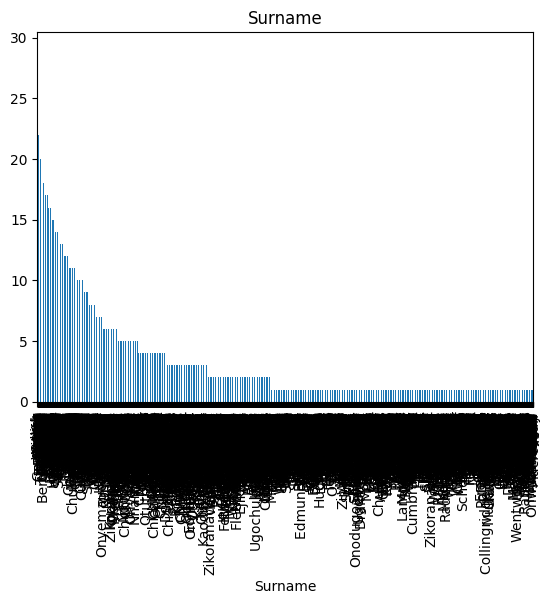

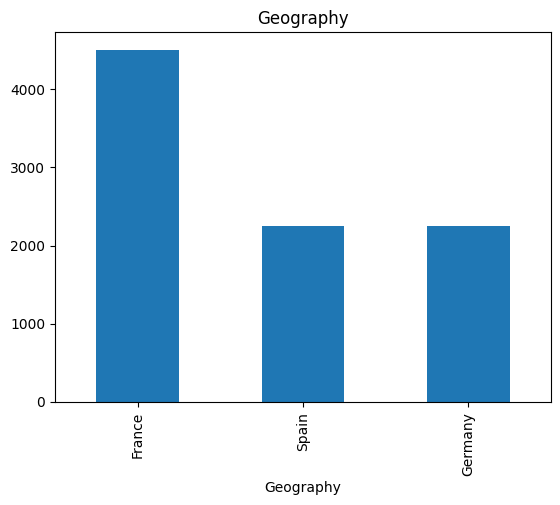

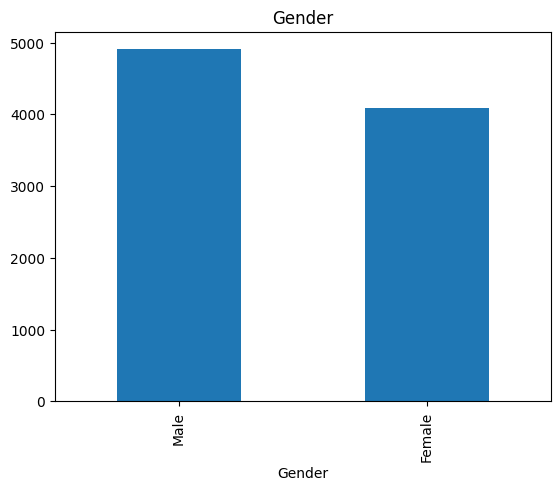

In [5]:
# review categorical variables

import matplotlib.pyplot as plt

categorical_df =df.select_dtypes(include=["object"])
categorical_df.info()

for col in categorical_df.columns:
    plt.figure()
    categorical_df[col].value_counts().plot(kind="bar")
    plt.title(col)
    plt.show



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9001 entries, 0 to 9000
Data columns (total 3 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   HasCrCard       9000 non-null   float64
 1   IsActiveMember  9001 non-null   float64
 2   Exited          9001 non-null   int64  
dtypes: float64(2), int64(1)
memory usage: 211.1 KB


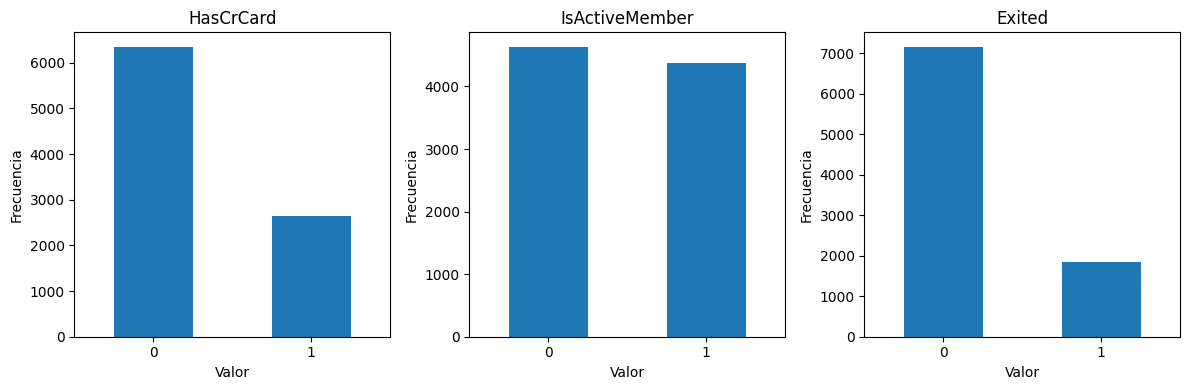

In [9]:
# review binary variables

binary = ['HasCrCard', 'IsActiveMember', 'Exited']

binary_df = df[binary]

binary_df.info()

fig, axes = plt.subplots(1, 3, figsize=(12, 4))

for i, col in enumerate(binary):
    binary_df[col].value_counts().plot(kind='bar', ax=axes[i])
    axes[i].set_title(col)
    axes[i].set_xlabel('Valor')
    axes[i].set_ylabel('Frecuencia')
    axes[i].set_xticks([0, 1])
    axes[i].set_xticklabels(['0', '1'], rotation=0)

plt.tight_layout()
plt.show()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9001 entries, 0 to 9000
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   CreditScore      9001 non-null   int64  
 1   Age              9000 non-null   float64
 2   Tenure           9001 non-null   int64  
 3   Balance          9001 non-null   float64
 4   EstimatedSalary  9001 non-null   float64
dtypes: float64(3), int64(2)
memory usage: 351.7 KB


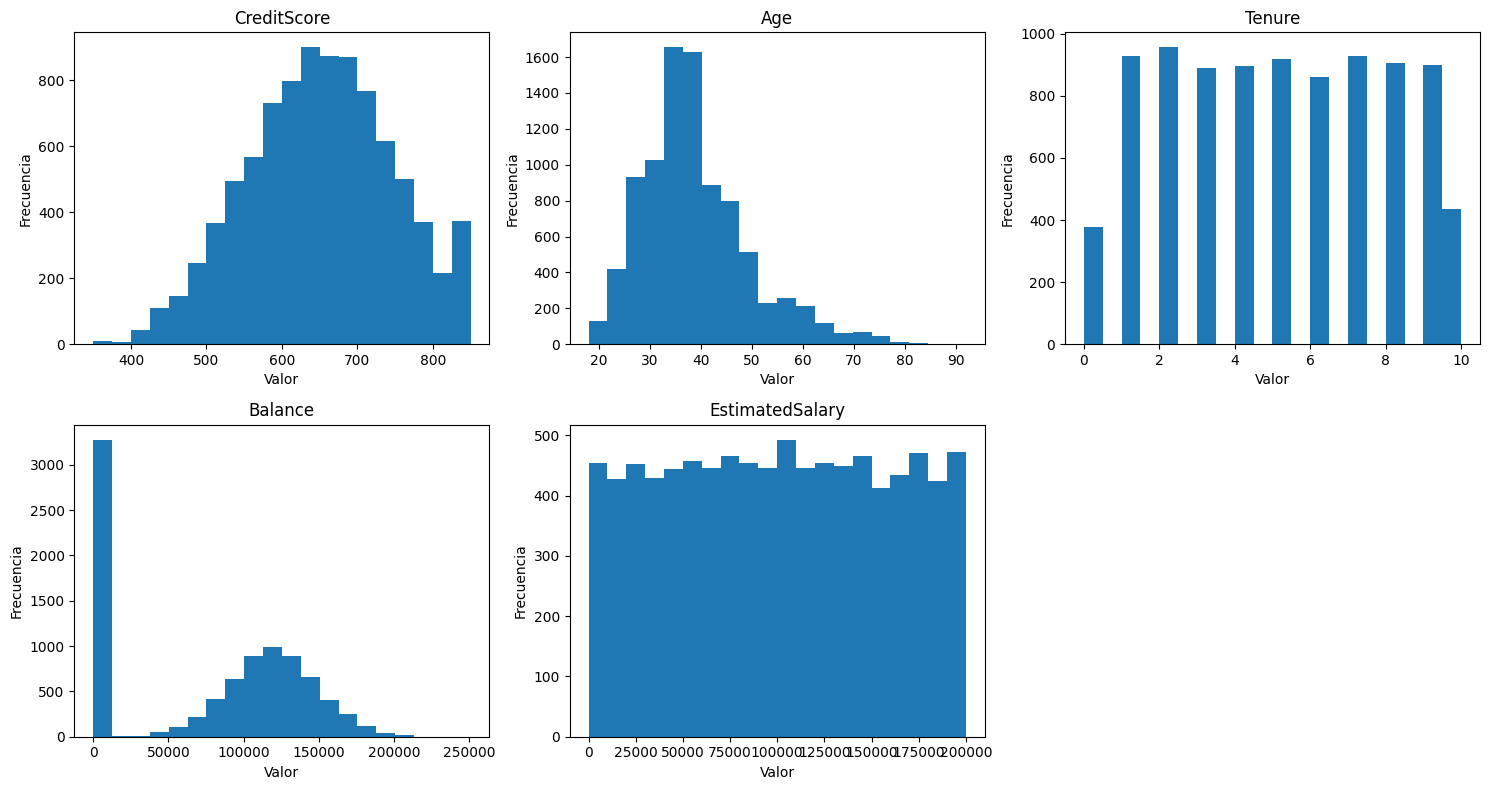

In [13]:
# review numerical variables

numerical = ['CreditScore', 'Age', 'Tenure', 'Balance', 'EstimatedSalary']

numerical_df = df[numerical]

numerical_df.info()

plt.close('all')
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(numerical):
    axes[i].hist(numerical_df[col].dropna(), bins=20)
    axes[i].set_title(col)
    axes[i].set_xlabel('Valor')
    axes[i].set_ylabel('Frecuencia')

axes[5].set_visible(False)
plt.tight_layout()
plt.show()

**EDA Conclusions**

From this Exploratory Data Analysis we can retrieve the following information:

The dataset contains 12 variables with 9,001 entries. Three of those variables have a missing value in one of the entries. It is sufficient to remove those entries to treat the missing values.

There are 3 categorical variables. The distribution of the frequency of surnames is not uniform, it is concentrated among less than half of the distinct surnames. Half of the entries in Geography are concentrated in France, while the other half is split equally between Spain and Germany, giving France higher representation in the data. Gender is approximately equally represented, with slightly more entries being male than female.

In addition to Gender, there are 3 binary variables. Most entries do not have a credit card and have not exited. The number of entries for Active Members is roughly equally split, with slightly more entries belonging to non-active members.

For the numeric variables, Credit Score shows a near-Gaussian distribution with a slight left skew, centered between 600 and 700. Age shows a distribution with high contentration between 30 and 40 and a right skew with a long right tail, centered between 30 and 40. Tenure and Estimated Salary are uniformly distributed. Balance shows a bimodal distribution — one normal distribution centered between 100,000 and 150,000, and another concentrated near 0.

### ML Pipeline

In this section the students are required to create a ML pipeline to predict whether the customer left the bank or not.

In [14]:
# import packages
import pandas as pd

In [17]:
# Load the dataset

#Remove null
df_no_null = df.dropna()
print(df_no_null.isnull().sum())

RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64


In [ ]:
# Preprocess the features - create a function or a class for it 
def transform(df: pd.DataFrame) -> pd.DataFrame:
    pass

In [ ]:
# balance the dataset (if you think it is necessary)
...

In [ ]:
# Train a decision tree model using the `train sample`
...

In [ ]:
# Check the accuracy of the model on the `test sample`
...

### MLFlow Integration

In this section the students are required to track the model and the parameters into MLFlow.

In [ ]:
# import packages for mlfow
import mlflow

Start a local Tracking server on port 8080 - it is necessary to import mlflow and open a new terminal

In [2]:
# Set our tracking server uri for logging on port 8080
...

Visit the MLFlow UI on `http://127.0.0.1:8080`

In [ ]:
# Create a new MLflow Experiment called `Practice Experiment - {Your Name}`
...

In [ ]:
# Start an MLflow run
with mlflow.start_run():
    # Log the hyperparameters

    # Log the loss metric

    # Set a tag that we can use to remind ourselves what this run was for
    # Info about tags is pending

    # Infer the model signature

    # Log the model

### Keep practicing

In [3]:
# Create a new experiment using other models or different parameters
...